In [73]:
from sklearn.datasets import make_moons

X, y = make_moons(
    n_samples=500,
    noise=0.25,
    random_state=42
)
import pandas as pd

df = pd.DataFrame(X, columns=['x1', 'x2'])
df['y'] = y

df.head()

,x1,x2,y
0,0.830948,-0.296546,1
1,1.088387,0.899693,0
2,1.135634,-0.462935,1
3,-0.082277,1.059718,0
4,0.443047,1.418977,0


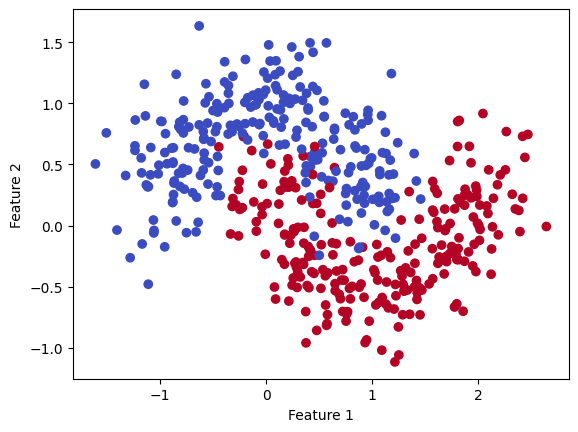

In [74]:
import matplotlib.pyplot as plt
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap='coolwarm'
)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [75]:
import numpy as np

p = np.mean(y)

base_score = np.log(p/(1-p))

print(base_score)
df['log_odds'] = base_score
df.head()

0.0


,x1,x2,y,log_odds
0,0.830948,-0.296546,1,0.0
1,1.088387,0.899693,0,0.0
2,1.135634,-0.462935,1,0.0
3,-0.082277,1.059718,0,0.0
4,0.443047,1.418977,0,0.0


In [76]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

print(sigmoid(0))
df['probability'] = sigmoid(df['log_odds'])
df.head()

0.5


,x1,x2,y,log_odds,probability
0,0.830948,-0.296546,1,0.0,0.5
1,1.088387,0.899693,0,0.0,0.5
2,1.135634,-0.462935,1,0.0,0.5
3,-0.082277,1.059718,0,0.0,0.5
4,0.443047,1.418977,0,0.0,0.5


In [77]:
df['gradient'] = df['probability'] - df['y']

In [78]:
df.head()

,x1,x2,y,log_odds,probability,gradient
0,0.830948,-0.296546,1,0.0,0.5,-0.5
1,1.088387,0.899693,0,0.0,0.5,0.5
2,1.135634,-0.462935,1,0.0,0.5,-0.5
3,-0.082277,1.059718,0,0.0,0.5,0.5
4,0.443047,1.418977,0,0.0,0.5,0.5


In [79]:
df['hessian'] = (
    df['probability'] *
    (1 - df['probability'])
)

In [80]:
df.head(10)

,x1,x2,y,log_odds,probability,gradient,hessian
0,0.830948,-0.296546,1,0.0,0.5,-0.5,0.25
1,1.088387,0.899693,0,0.0,0.5,0.5,0.25
2,1.135634,-0.462935,1,0.0,0.5,-0.5,0.25
3,-0.082277,1.059718,0,0.0,0.5,0.5,0.25
4,0.443047,1.418977,0,0.0,0.5,0.5,0.25
5,1.300300,-0.537628,1,0.0,0.5,-0.5,0.25
6,1.143109,-0.215442,1,0.0,0.5,-0.5,0.25
7,0.131665,1.265140,0,0.0,0.5,0.5,0.25
8,0.486750,0.539479,0,0.0,0.5,0.5,0.25
9,1.678649,-0.396435,1,0.0,0.5,-0.5,0.25


In [81]:
G = df['gradient'].sum()
H = df['hessian'].sum()

print("G =", G)
print("H =", H)

G = 0.0
H = 125.0


In [82]:
def gain(GL, HL, GR, HR, G, H, lam=1):

    left = (GL**2)/(HL + lam)
    right = (GR**2)/(HR + lam)
    parent = (G**2)/(H + lam)

    return 0.5 * (left + right - parent)

In [83]:
temp = df.sort_values('x1').reset_index(drop=True)

In [84]:
best_gain = -float('inf')
best_split = None

for i in range(1, len(temp)):

    left = temp.iloc[:i]
    right = temp.iloc[i:]

    GL = left['gradient'].sum()
    HL = left['hessian'].sum()

    GR = right['gradient'].sum()
    HR = right['hessian'].sum()

    current_gain = gain(
        GL, HL,
        GR, HR,
        G, H
    )

    if current_gain > best_gain:

        best_gain = current_gain

        best_split = (
            temp.iloc[i-1]['x1']
            + temp.iloc[i]['x1']
        ) / 2

In [85]:
print("Best Split:", best_split)
print("Best Gain:", best_gain)

Best Split: 1.243847380990484
Best Gain: 62.76266713581984


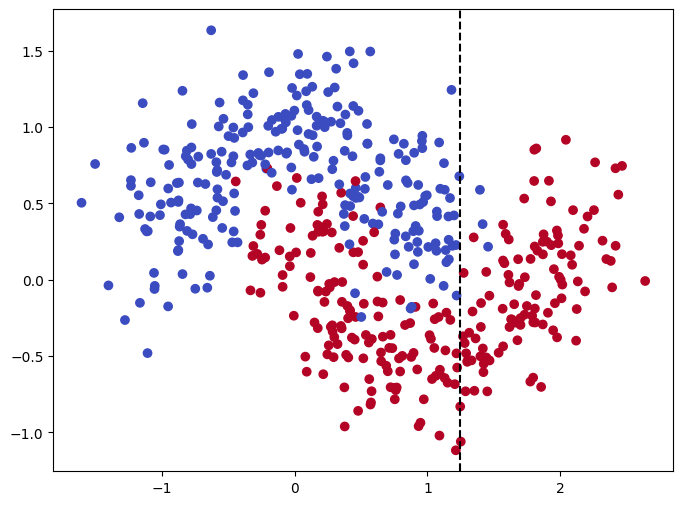

In [86]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['x1'],
    df['x2'],
    c=df['y'],
    cmap='coolwarm'
)

plt.axvline(
    best_split,
    color='black',
    linestyle='--'
)

plt.show()

In [87]:
left = temp[temp['x1'] <= best_split]
right = temp[temp['x1'] > best_split]

In [88]:
lam = 1

GL = left['gradient'].sum()
HL = left['hessian'].sum()

GR = right['gradient'].sum()
HR = right['hessian'].sum()

w_left = -GL / (HL + lam)
w_right = -GR / (HR + lam)

print(w_left, w_right)

-0.5408163265306123 1.8275862068965518


In [89]:
df['tree_pred'] = np.where(
    df['x1'] <= best_split,
    w_left,
    w_right
)

In [90]:
df[['x1','y','tree_pred']].head()

,x1,y,tree_pred
0,0.830948,1,-0.540816
1,1.088387,0,-0.540816
2,1.135634,1,-0.540816
3,-0.082277,0,-0.540816
4,0.443047,0,-0.540816


In [91]:
eta = 0.3

In [92]:
df['log_odds'] = (
    df['log_odds']
    + eta * df['tree_pred']
)

In [93]:
df['probability'] = sigmoid(
    df['log_odds']
)

In [94]:
df['gradient'] = (
    df['probability']
    - df['y']
)

df['hessian'] = (
    df['probability']
    * (1 - df['probability'])
)

In [95]:
print(df[['y','probability']].head(20))

    y  probability
0   1     0.459528
1   0     0.459528
2   1     0.459528
3   0     0.459528
4   0     0.459528
5   1     0.633735
6   1     0.459528
7   0     0.459528
8   0     0.459528
9   1     0.633735
10  0     0.459528
11  0     0.459528
12  1     0.633735
13  0     0.459528
14  1     0.633735
15  1     0.633735
16  1     0.633735
17  0     0.459528
18  1     0.459528
19  1     0.633735


In [96]:
from sklearn.model_selection import train_test_split

X = df[['x1', 'x2']]
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [97]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective='binary:logistic',
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [98]:
y_pred = xgb.predict(X_test)

In [99]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)

Accuracy: 0.96


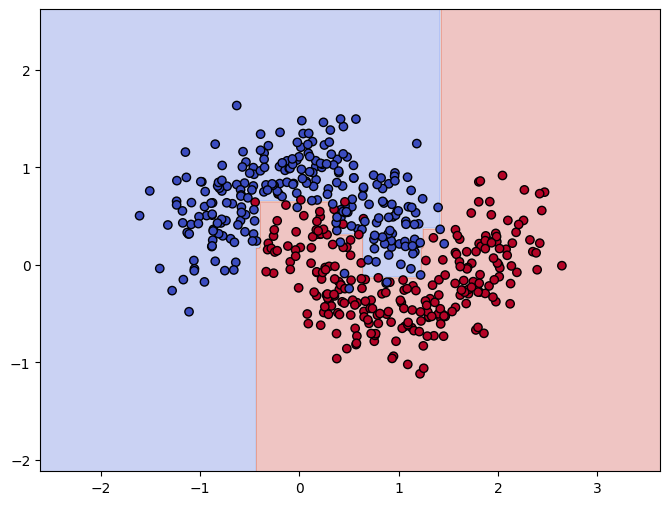

In [100]:


x_min, x_max = X['x1'].min()-1, X['x1'].max()+1
y_min, y_max = X['x2'].min()-1, X['x2'].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

Z = xgb.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.3,
    cmap='coolwarm'
)

plt.scatter(
    X['x1'],
    X['x2'],
    c=y,
    cmap='coolwarm',
    edgecolors='k'
)

plt.show()

In [101]:
from sklearn.model_selection import GridSearchCV


In [102]:
param_grid = {
    'n_estimators': [50,100,200],
    'max_depth': [2,3,4,5],
    'learning_rate': [0.01,0.05,0.1,0.2],
    'subsample': [0.8,1.0]
}

In [103]:
xgb = XGBClassifier(
    objective='binary:logistic',
    random_state=42
)

In [104]:
grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 96 candidates, totalling 480 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [2, 3, ...], 'n_estimators': [50, 100, ...], 'subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and param

In [105]:
{
 'learning_rate': 0.1,
 'max_depth': 3,
 'n_estimators': 100,
 'subsample': 1.0
}

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}

In [106]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print(
    accuracy_score(
        y_test,
        y_pred
    )
)

0.95


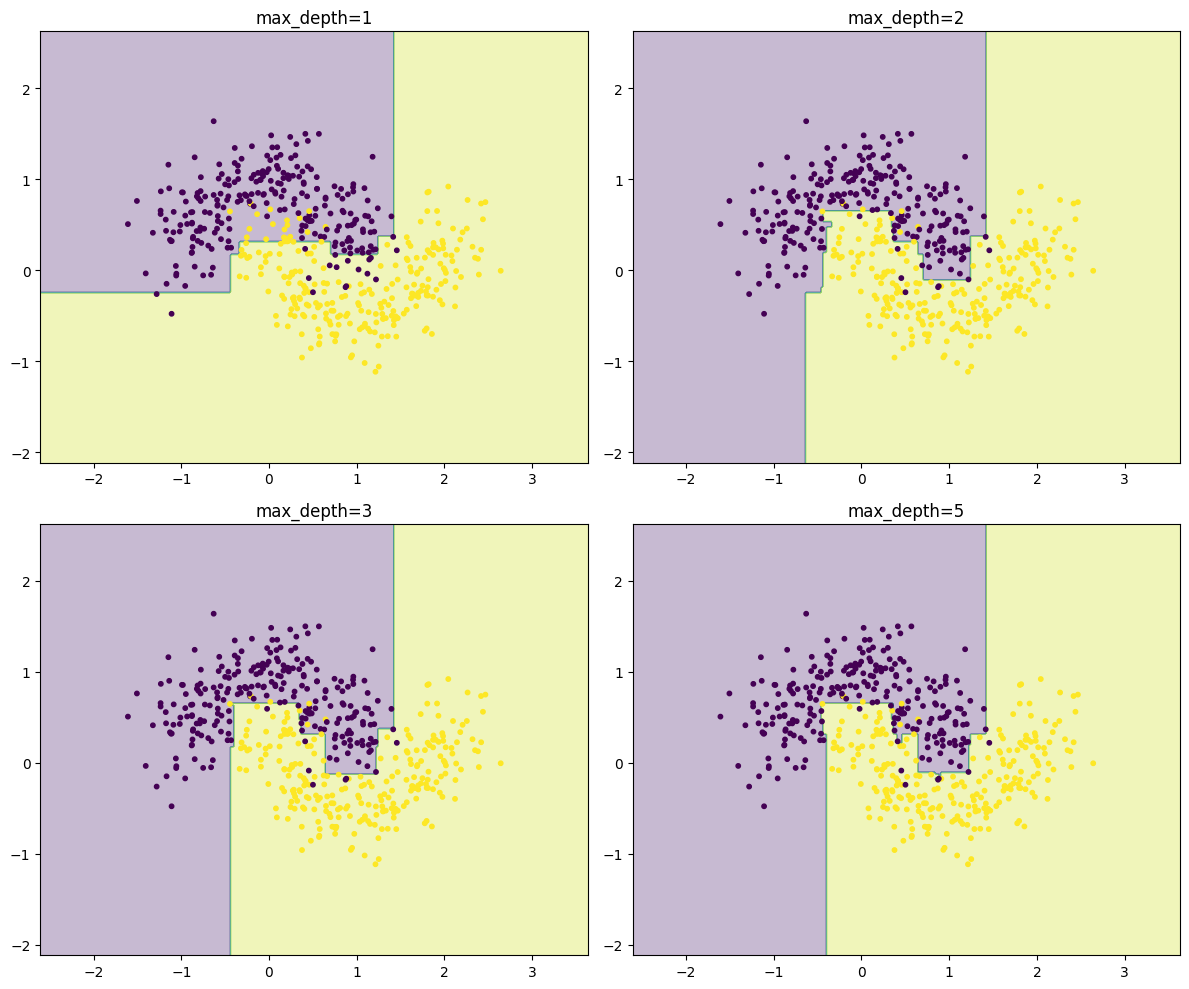

In [107]:
fig, axes = plt.subplots(2, 2, figsize=(12,10))

depths = [1,2,3,5]

for ax, depth in zip(axes.ravel(), depths):

    model = XGBClassifier(
        max_depth=depth,
        n_estimators=100,
        learning_rate=0.1,
        subsample=1.0,
        random_state=42
    )

    model.fit(X_train, y_train)

    xx, yy = np.meshgrid(
        np.arange(X['x1'].min()-1, X['x1'].max()+1, 0.02),
        np.arange(X['x2'].min()-1, X['x2'].max()+1, 0.02)
    )

    Z = model.predict(
        np.c_[xx.ravel(), yy.ravel()]
    )

    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3)
    ax.scatter(X['x1'], X['x2'], c=y, s=10)

    ax.set_title(f"max_depth={depth}")

plt.tight_layout()
plt.show()

C:\Users\ACER\AppData\Local\Temp\ipykernel_4648\2495187763.py:38: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


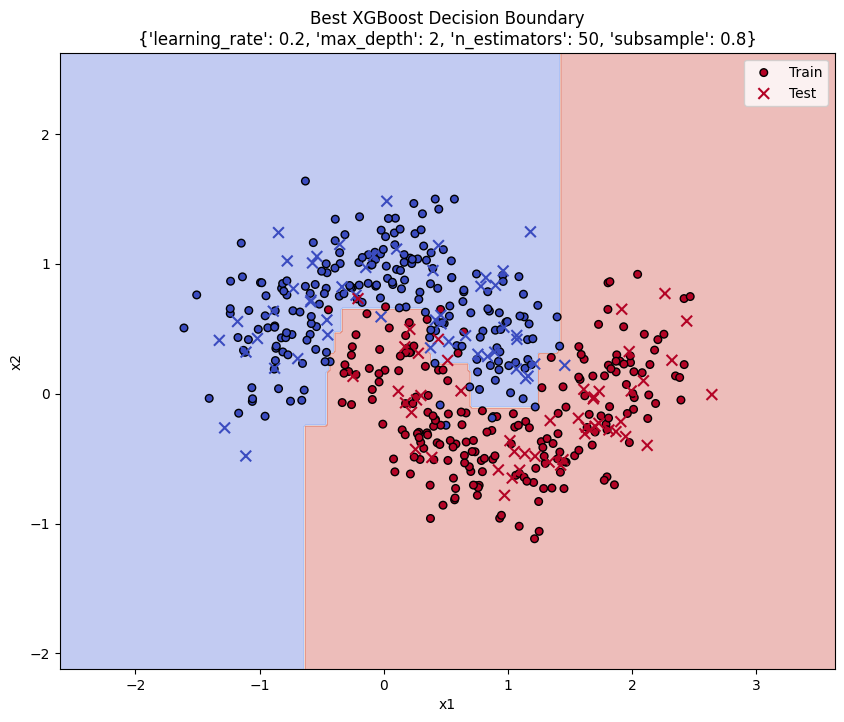

In [108]:
import numpy as np
import matplotlib.pyplot as plt

x_min, x_max = X['x1'].min()-1, X['x1'].max()+1
y_min, y_max = X['x2'].min()-1, X['x2'].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

Z = best_model.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,8))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.35,
    cmap='coolwarm'
)

plt.scatter(
    X_train['x1'],
    X_train['x2'],
    c=y_train,
    cmap='coolwarm',
    edgecolors='k',
    s=30,
    label='Train'
)

plt.scatter(
    X_test['x1'],
    X_test['x2'],
    c=y_test,
    cmap='coolwarm',
    edgecolors='black',
    marker='x',
    s=60,
    label='Test'
)

plt.title(
    f"Best XGBoost Decision Boundary\n"
    f"{grid.best_params_}"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()

plt.show()